In [242]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 300
# set tight layout for all plots
plt.rcParams['figure.autolayout'] = True

In [243]:
Cs137_path='data/sipm_spectroscopy/vp2ps_20250325-100124_cs137_1h_20cm.csv'
Co60_path='data/sipm_spectroscopy/vp2ps_20250323-150545_co60_18h.csv'
Na22_path='data/sipm_spectroscopy/vp2ps_20250317-162839_na22_1h.csv'
bg_path='data/sipm_spectroscopy/vp2ps_20250324-095000_bg_24h.csv'
Cs137_df = pd.read_csv(Cs137_path)
Co60_df = pd.read_csv(Co60_path)
Na22_df = pd.read_csv(Na22_path)
bg_df = pd.read_csv(bg_path)

Cs137_df['mV'] = Cs137_df['V'] * 1000
Co60_df['mV'] = Co60_df['V'] * 1000
Na22_df['mV'] = Na22_df['V'] * 1000
bg_df['mV'] = bg_df['V'] * 1000

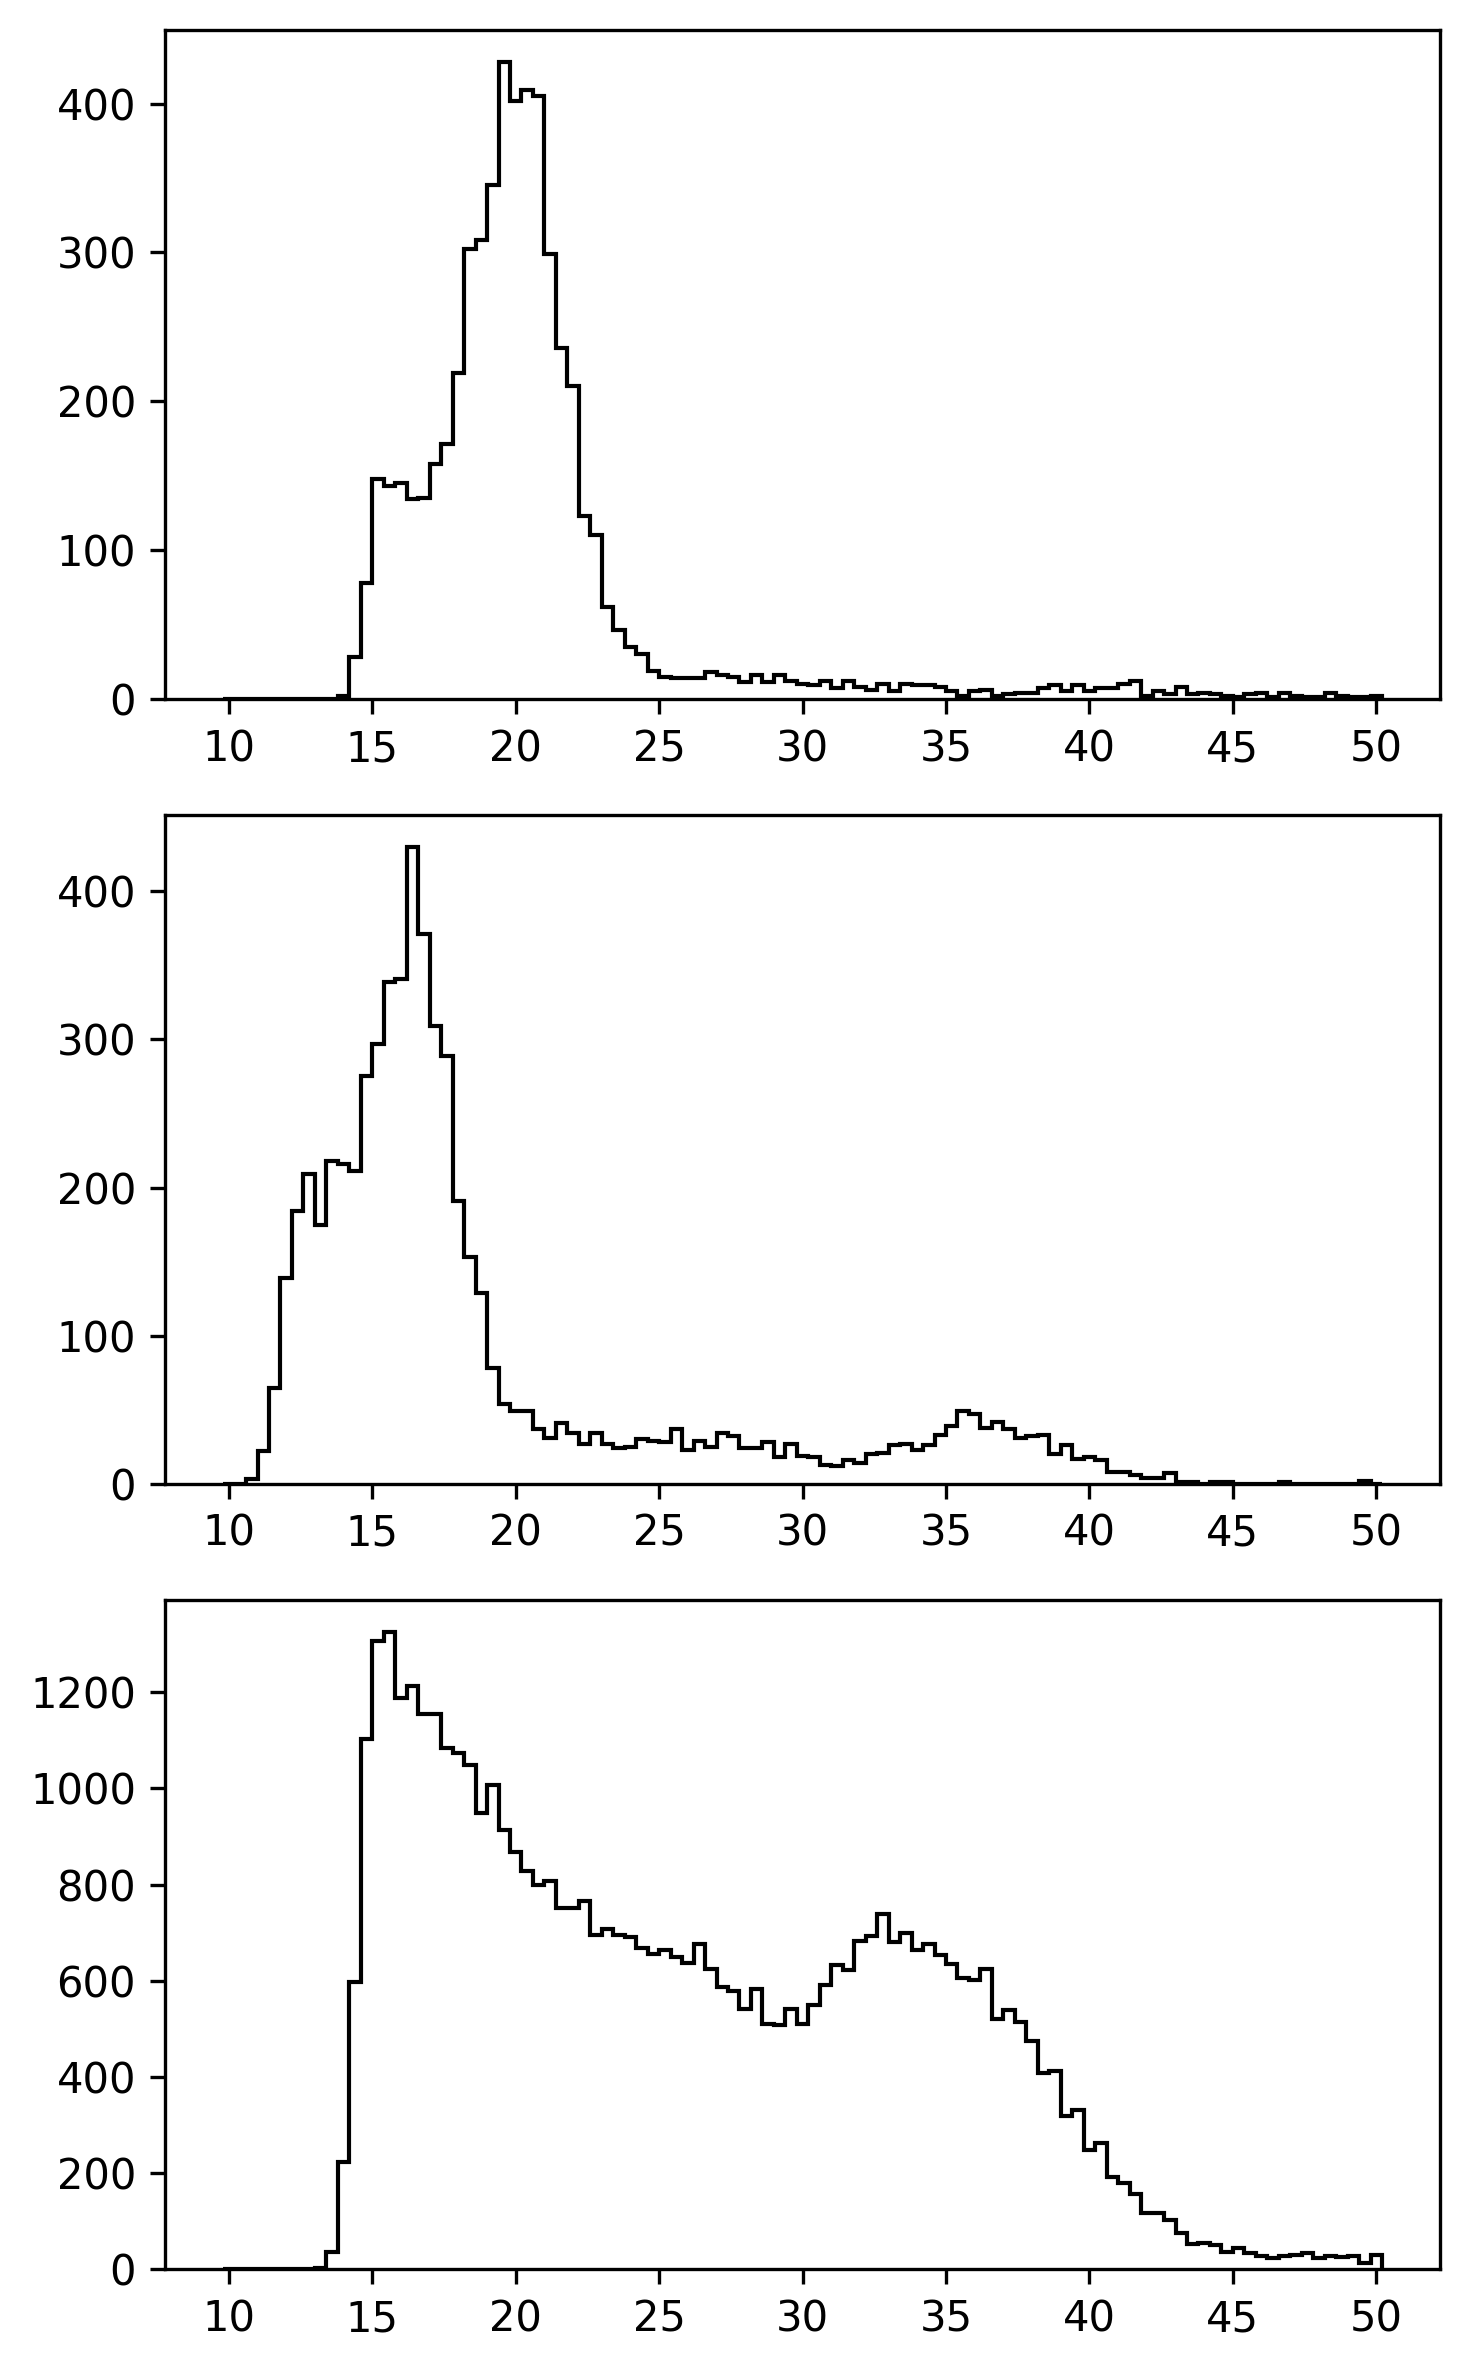

In [244]:
min =10 
max = 50
step = 0.4 #mV
hist_bins = np.arange(min-step/2, max+step/2, step)
fig, ax = plt.subplots(3,1,figsize=(5, 8))
ax[0].hist(Cs137_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
ax[1].hist(Na22_df['mV'], range=(min,max),bins=hist_bins, color='black', label='Na22', histtype='step')
ax[2].hist(Co60_df['mV'], range=(min,max),bins=hist_bins, color='black', label='Co60', histtype='step')
plt.show()


Text(0.5, 1.0, 'Background spectrum')

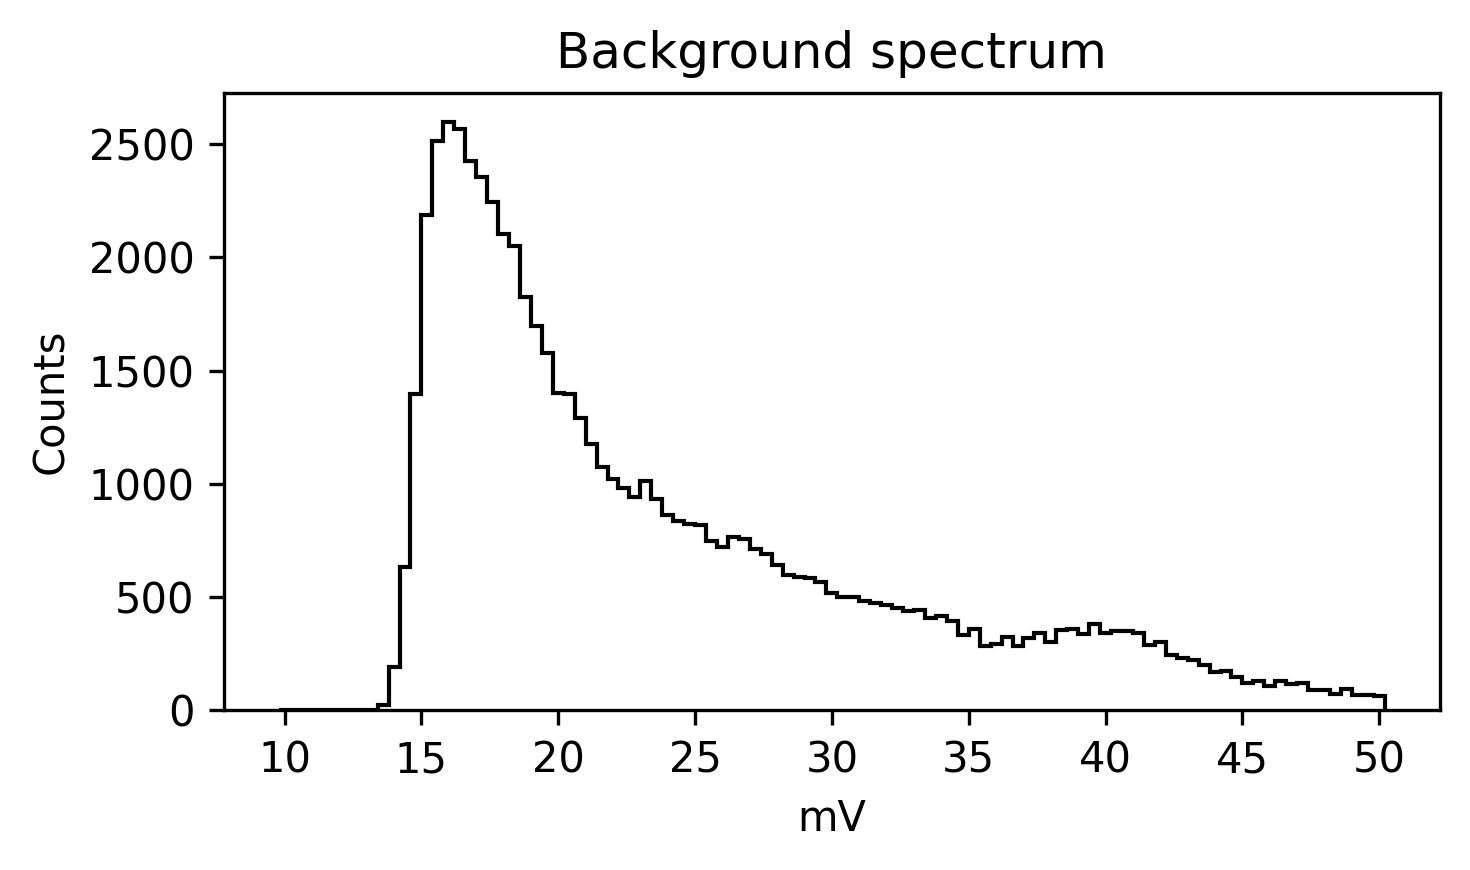

In [245]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(bg_df['mV'], range=(min,max), bins=hist_bins, color='black', label='bg', histtype='step')
ax.set_xlabel('mV') 
ax.set_ylabel('Counts') 
ax.set_title('Background spectrum')

/tmp/ipykernel_164531/712768787.py:6: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B * np.exp(-x / tau)


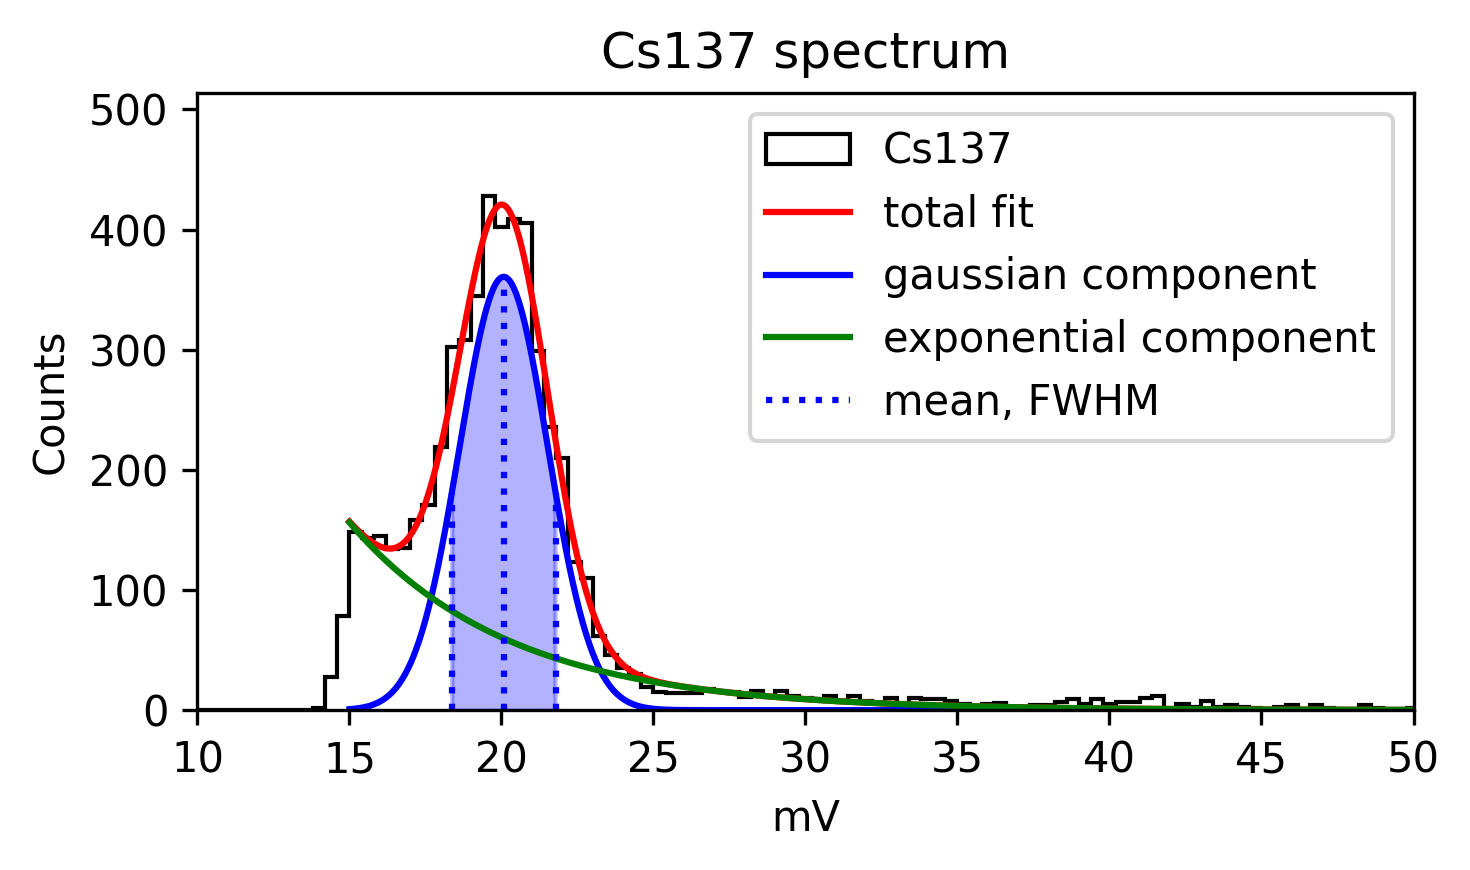

In [246]:

fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Cs137_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

def fit_func(x, A, mu, sigma, B, tau):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B * np.exp(-x / tau)

fit_range = (15, 50)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
initial_guess = [1e5, 20, 2, 1e4, 10] 

popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0)
y_exponential = fit_func(x_fit, 0, 0, 0, popt[3], popt[4])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian, color='blue', label='gaussian component')
ax.plot(x_fit, y_exponential, color='green', label='exponential component')
fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
peak_middle = popt[1]
ax.vlines(peak_middle, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle - fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle + fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')

ax.fill_between(x_fit, y_gaussian, 0, where=(x_fit >= peak_middle - fwhm/2) & (x_fit <= peak_middle + fwhm/2), color='blue', alpha=0.3)
Cs137_peak1_mean=popt[1]
Cs137_peak1_fwhm=fwhm

ax.legend()
ax.set_title('Cs137 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')
ax_cs137 = ax
plt.show()

/tmp/ipykernel_164531/2027811354.py:10: RuntimeWarning: divide by zero encountered in divide
  return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * np.exp(-x / tau)


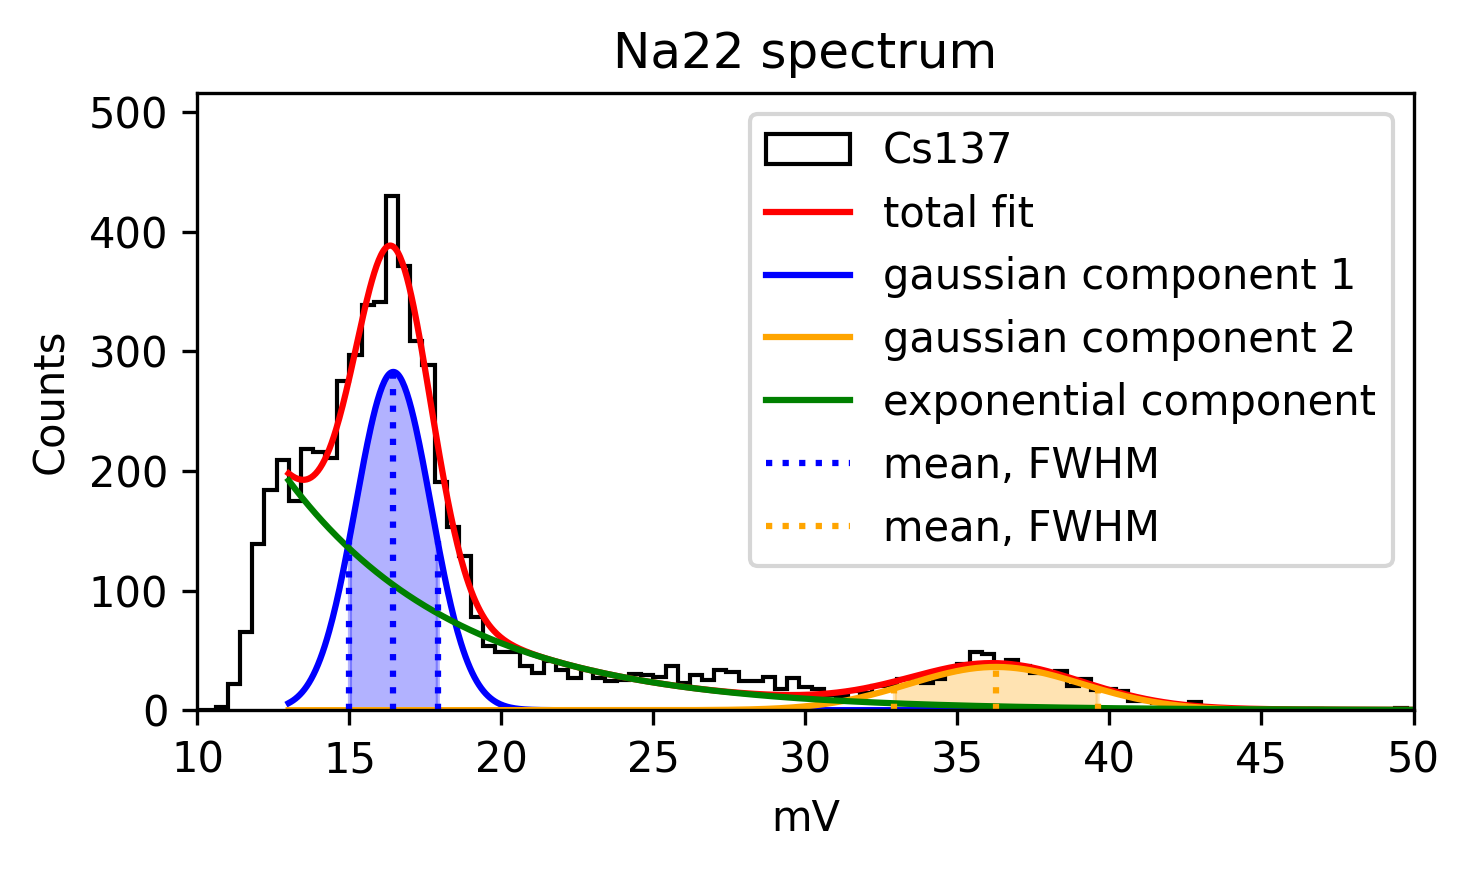

In [247]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Na22_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (13, 50)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus an exponential curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, tau):
    return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * np.exp(-x / tau)
initial_guess = [1e4, 17, 2, 1e4, 36, 2, 1e4, 10]
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0)
y_exponential = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_exponential, color='green', label='exponential component')
fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
peak_middle1 = popt[1]
peak_middle2 = popt[4]
ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')

ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Na22_peak1_mean=popt[1]
Na22_peak1_fwhm=fwhm1
Na22_peak2_mean=popt[4]
Na22_peak2_fwhm=fwhm2

ax.legend()
ax.set_title('Na22 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')
ax_na22 = ax
plt.show()

/tmp/ipykernel_164531/3268467129.py:10: RuntimeWarning: divide by zero encountered in divide
  return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * x**2 + C * x + D


fit parameters:
param 0: 286.04
param 1: 32.84
param 2: 1.74
param 3: 290.62
param 4: 36.80
param 5: 2.12
param 6: 0.53
param 7: -66.43
param 8: 1978.13


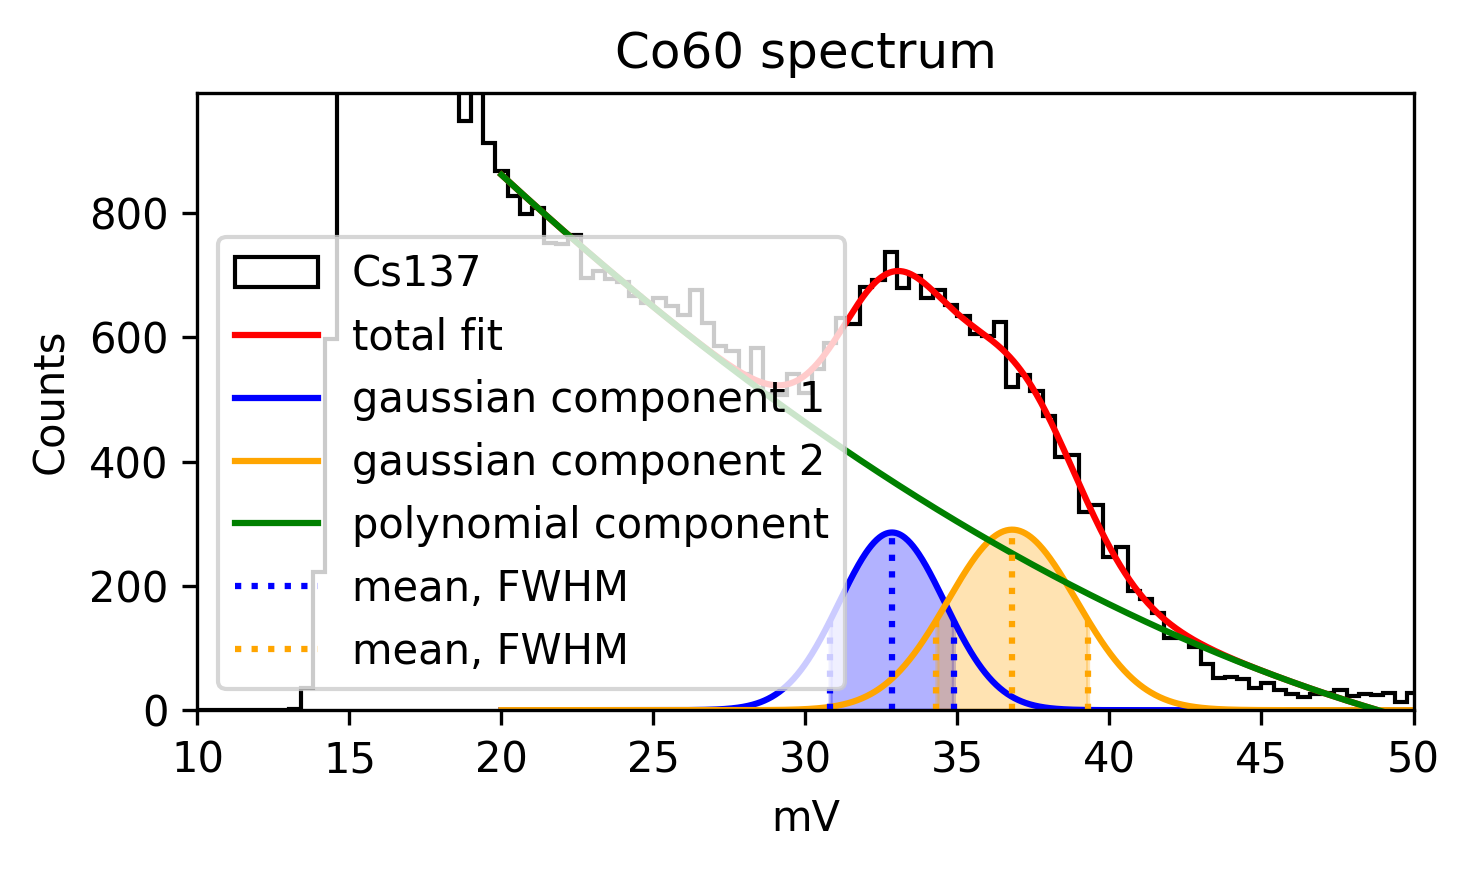

In [248]:

fig, ax = plt.subplots(1,1,figsize=(5,3))
count, bins, _ = ax.hist(Co60_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (20, 50)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus a quadratic curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, C, D):
    return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * x**2 + C * x + D
initial_guess = [1e2, 33, 2, 1e2, 36, 2, 1e-1, 1e1,1e3]
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess, maxfev=10000)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0,0)
y_exponential = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7], popt[8])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_exponential, color='green', label='polynomial component')

fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
peak_middle1 = popt[1]
peak_middle2 = popt[4]
ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Co60_peak1_mean=popt[1]
Co60_peak1_fwhm=fwhm1
Co60_peak2_mean=popt[4]
Co60_peak2_fwhm=fwhm2


# present the fit parameters
print('fit parameters:')
for i, param in enumerate(popt):
    print(f'param {i}: {param:.2f}')

ax.legend()
ax.set_title('Co60 spectrum')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')
ax_co60 = ax
plt.show()

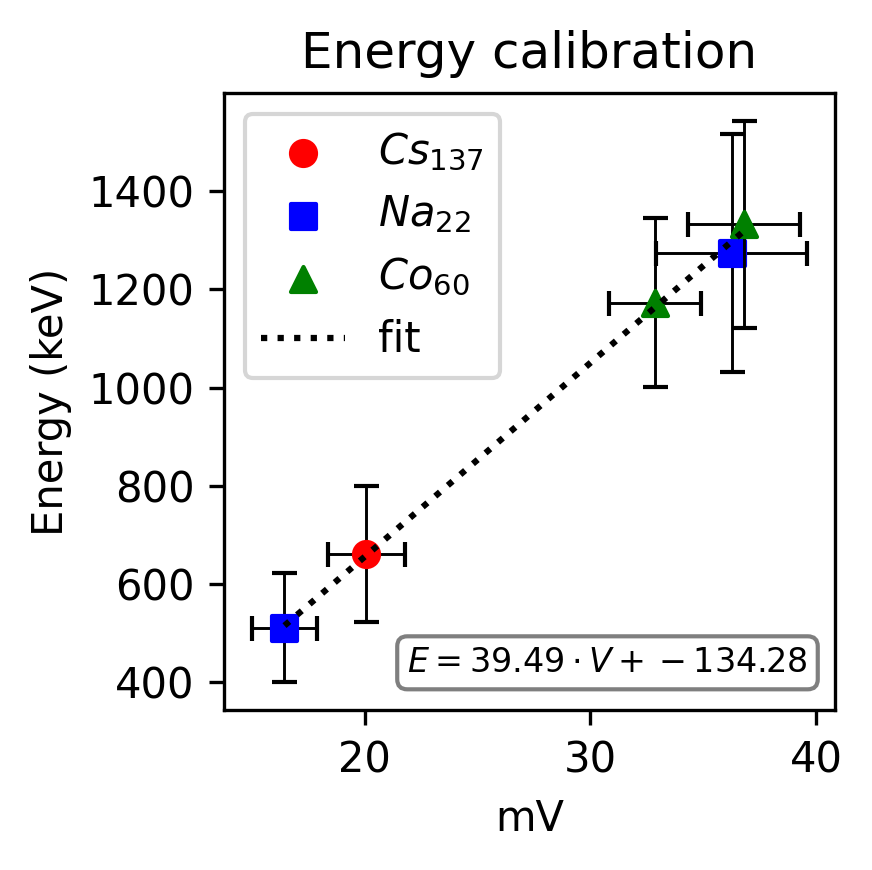

In [256]:


fig, ax = plt.subplots(1,1,figsize=(3,3))

Cs137_peak1_energy_keV = 661.7
Na22_peak1_energy_keV = 511
Na22_peak2_energy_keV = 1274.5
Co60_peak1_energy_keV = 1173.2
Co60_peak2_energy_keV = 1332.5

#plot the energy calibration
# fit a line to the data
def linear_func(x, a, b):
    return a * x + b
x_data = np.array([Cs137_peak1_mean, Na22_peak1_mean, Na22_peak2_mean, Co60_peak1_mean, Co60_peak2_mean])
y_data = np.array([Cs137_peak1_energy_keV, Na22_peak1_energy_keV, Na22_peak2_energy_keV, Co60_peak1_energy_keV, Co60_peak2_energy_keV])
popt, pcov = curve_fit(linear_func, x_data, y_data)
x_fit = np.linspace(np.min(x_data), np.max(x_data), 1000)
y_fit = linear_func(x_fit, *popt)
mV_to_energy_A = popt[0]
mV_to_energy_B = popt[1]
def mV_to_keV(mV):
    return mV_to_energy_A * mV + mV_to_energy_B
def keV_to_mV(keV):
    return (keV - mV_to_energy_B) / mV_to_energy_A

# scatter the cesium as red circles
yerr= Cs137_peak1_energy_keV - mV_to_keV(Cs137_peak1_mean - Cs137_peak1_fwhm)
ax.errorbar(Cs137_peak1_mean, Cs137_peak1_energy_keV, xerr=Cs137_peak1_fwhm/2, yerr=yerr, fmt='none', color='black', capsize=3, elinewidth=0.7)
ax.scatter(Cs137_peak1_mean, Cs137_peak1_energy_keV, color='red', label=r'$Cs_{137}$', marker='o', zorder=2)
# scatter the sodium as blue squared
yerr = Na22_peak1_energy_keV - mV_to_keV(Na22_peak1_mean - Na22_peak1_fwhm)
ax.errorbar(Na22_peak1_mean, Na22_peak1_energy_keV, xerr=Na22_peak1_fwhm/2, yerr=yerr, fmt='none', color='black', capsize=3, elinewidth=0.7)
ax.scatter(Na22_peak1_mean, Na22_peak1_energy_keV, color='blue', label=r'$Na_{22}$', marker='s', zorder=2)

yerr = Na22_peak2_energy_keV - mV_to_keV(Na22_peak2_mean - Na22_peak2_fwhm)
ax.errorbar(Na22_peak2_mean, Na22_peak2_energy_keV, xerr=Na22_peak2_fwhm/2, yerr=yerr, fmt='none', color='black', capsize=3, elinewidth=0.7)
ax.scatter(Na22_peak2_mean, Na22_peak2_energy_keV, color='blue', marker='s', zorder=2)
# scatter the cobalt as green triangles
yerr = Co60_peak1_energy_keV - mV_to_keV(Co60_peak1_mean - Co60_peak1_fwhm)
ax.errorbar(Co60_peak1_mean, Co60_peak1_energy_keV, xerr=Co60_peak1_fwhm/2, yerr=yerr, fmt='none', color='black', capsize=3, elinewidth=0.7)
ax.scatter(Co60_peak1_mean, Co60_peak1_energy_keV, color='green', label=r'$Co_{60}$', marker='^', zorder=2)
yerr = Co60_peak2_energy_keV - mV_to_keV(Co60_peak2_mean - Co60_peak2_fwhm)
ax.errorbar(Co60_peak2_mean, Co60_peak2_energy_keV, xerr=Co60_peak2_fwhm/2, yerr=yerr, fmt='none', color='black', capsize=3, elinewidth=0.7)
ax.scatter(Co60_peak2_mean, Co60_peak2_energy_keV, color='green', marker='^', zorder=2)

ax.plot(x_fit, y_fit, color='black', label='fit', linestyle='dotted')

# display the fit parameters as a latex equation in the plot on the lower right corner
fit_params = rf'$E = {popt[0]:.2f} \cdot V + {popt[1]:.2f}$'
ax.text(0.3, 0.05, fit_params, transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


ax.set_xlabel('mV')
ax.set_ylabel('Energy (keV)')
ax.set_title('Energy calibration')
ax.legend()
plt.show()



<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\%'
<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_164531/1979510303.py:28: SyntaxWarning: invalid escape sequence '\c'
  fit_params = r'$\Delta E/E =$' + f'$ {popt[0]*100:.4f} \cdot E + {popt[1]*100:.2f} \%$'
/tmp/ipykernel_164531/1979510303.py:28: SyntaxWarning: invalid escape sequence '\%'
  fit_params = r'$\Delta E/E =$' + f'$ {popt[0]*100:.4f} \cdot E + {popt[1]*100:.2f} \%$'


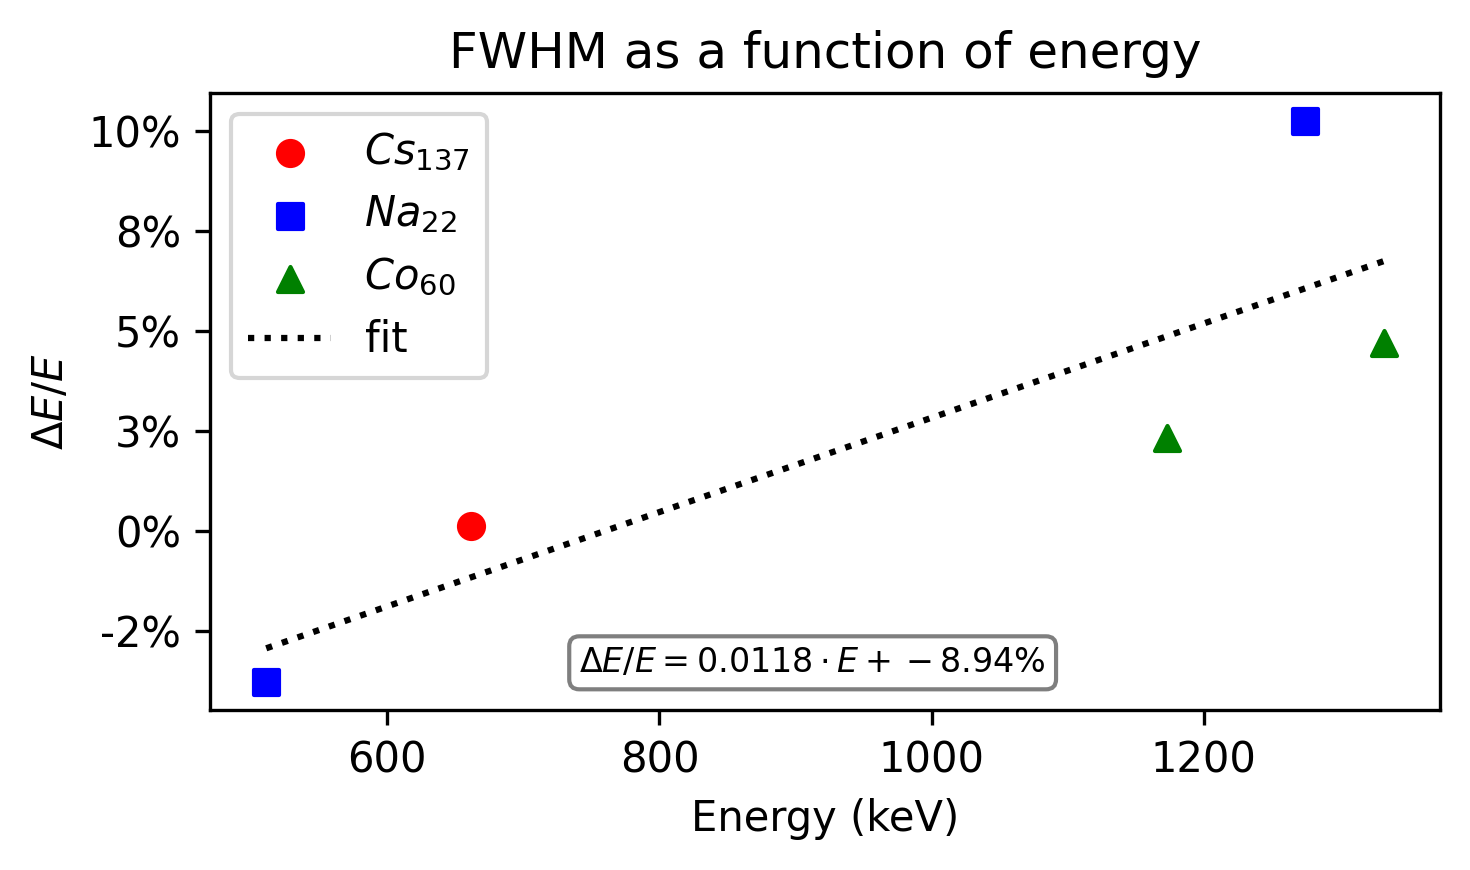

In [255]:
# plot the fwhm of the peaks as a function of energy
fig, ax = plt.subplots(1,1,figsize=(5,3))
# scatter the cesium as red circles
Cs137_peak1_dE = mV_to_keV(Cs137_peak1_fwhm)/Cs137_peak1_energy_keV
Na22_peak1_dE = mV_to_keV(Na22_peak1_fwhm)/Na22_peak1_energy_keV
Na22_peak2_dE = mV_to_keV(Na22_peak2_fwhm)/Na22_peak2_energy_keV
Co60_peak1_dE = mV_to_keV(Co60_peak1_fwhm)/Co60_peak1_energy_keV
Co60_peak2_dE = mV_to_keV(Co60_peak2_fwhm)/Co60_peak2_energy_keV
ax.scatter(Cs137_peak1_energy_keV, Cs137_peak1_dE, color='red', label=r'$Cs_{137}$', marker='o', zorder=2)
# scatter the sodium as blue squared
ax.scatter(Na22_peak1_energy_keV, Na22_peak1_dE, color='blue', label=r'$Na_{22}$', marker='s', zorder=2)
ax.scatter(Na22_peak2_energy_keV, Na22_peak2_dE, color='blue',  marker='s', zorder=2)
# scatter the cobalt as green triangles
ax.scatter(Co60_peak1_energy_keV, Co60_peak1_dE, color='green', label=r'$Co_{60}$', marker='^', zorder=2)
ax.scatter(Co60_peak2_energy_keV, Co60_peak2_dE, color='green', marker='^', zorder=2)


# fit a line to the data
def linear_func(x, a, b):
    return a * x + b
x_data = np.array([Cs137_peak1_energy_keV, Na22_peak1_energy_keV, Na22_peak2_energy_keV, Co60_peak1_energy_keV, Co60_peak2_energy_keV])
y_data = np.array([Cs137_peak1_dE, Na22_peak1_dE, Na22_peak2_dE, Co60_peak1_dE, Co60_peak2_dE])
popt, pcov = curve_fit(linear_func, x_data, y_data)
x_fit = np.linspace(np.min(x_data), np.max(x_data), 1000)
y_fit = linear_func(x_fit, *popt)
ax.plot(x_fit, y_fit, color='black', label='fit', linestyle='dotted')
# display the fit parameters as a latex equation in the plot on the lower right corner
fit_params = r'$\Delta E/E =$' + f'$ {popt[0]*100:.4f} \cdot E + {popt[1]*100:.2f} \%$'
ax.text(0.3, 0.05, fit_params, transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'$\Delta E/E$')
# display y axis in percent
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0f}%'.format(x * 100)))
ax.set_title('FWHM as a function of energy')
ax.legend()
plt.show()

In [251]:

# add a column in the dataframes for the energy
Cs137_df['keV'] = mV_to_keV(Cs137_df['mV'])
Na22_df['keV'] = mV_to_keV(Na22_df['mV'])
Co60_df['keV'] = mV_to_keV(Co60_df['mV'])

/tmp/ipykernel_164531/4143124676.py:6: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B * np.exp(-x / tau)
/tmp/ipykernel_164531/4143124676.py:57: RuntimeWarning: divide by zero encountered in divide
  return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * np.exp(-x / tau)
/tmp/ipykernel_164531/4143124676.py:109: RuntimeWarning: divide by zero encountered in divide
  return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * x**2 + C * x + D


fit parameters:
param 0: 286.04
param 1: 32.84
param 2: 1.74
param 3: 290.62
param 4: 36.80
param 5: 2.12
param 6: 0.53
param 7: -66.43
param 8: 1978.13


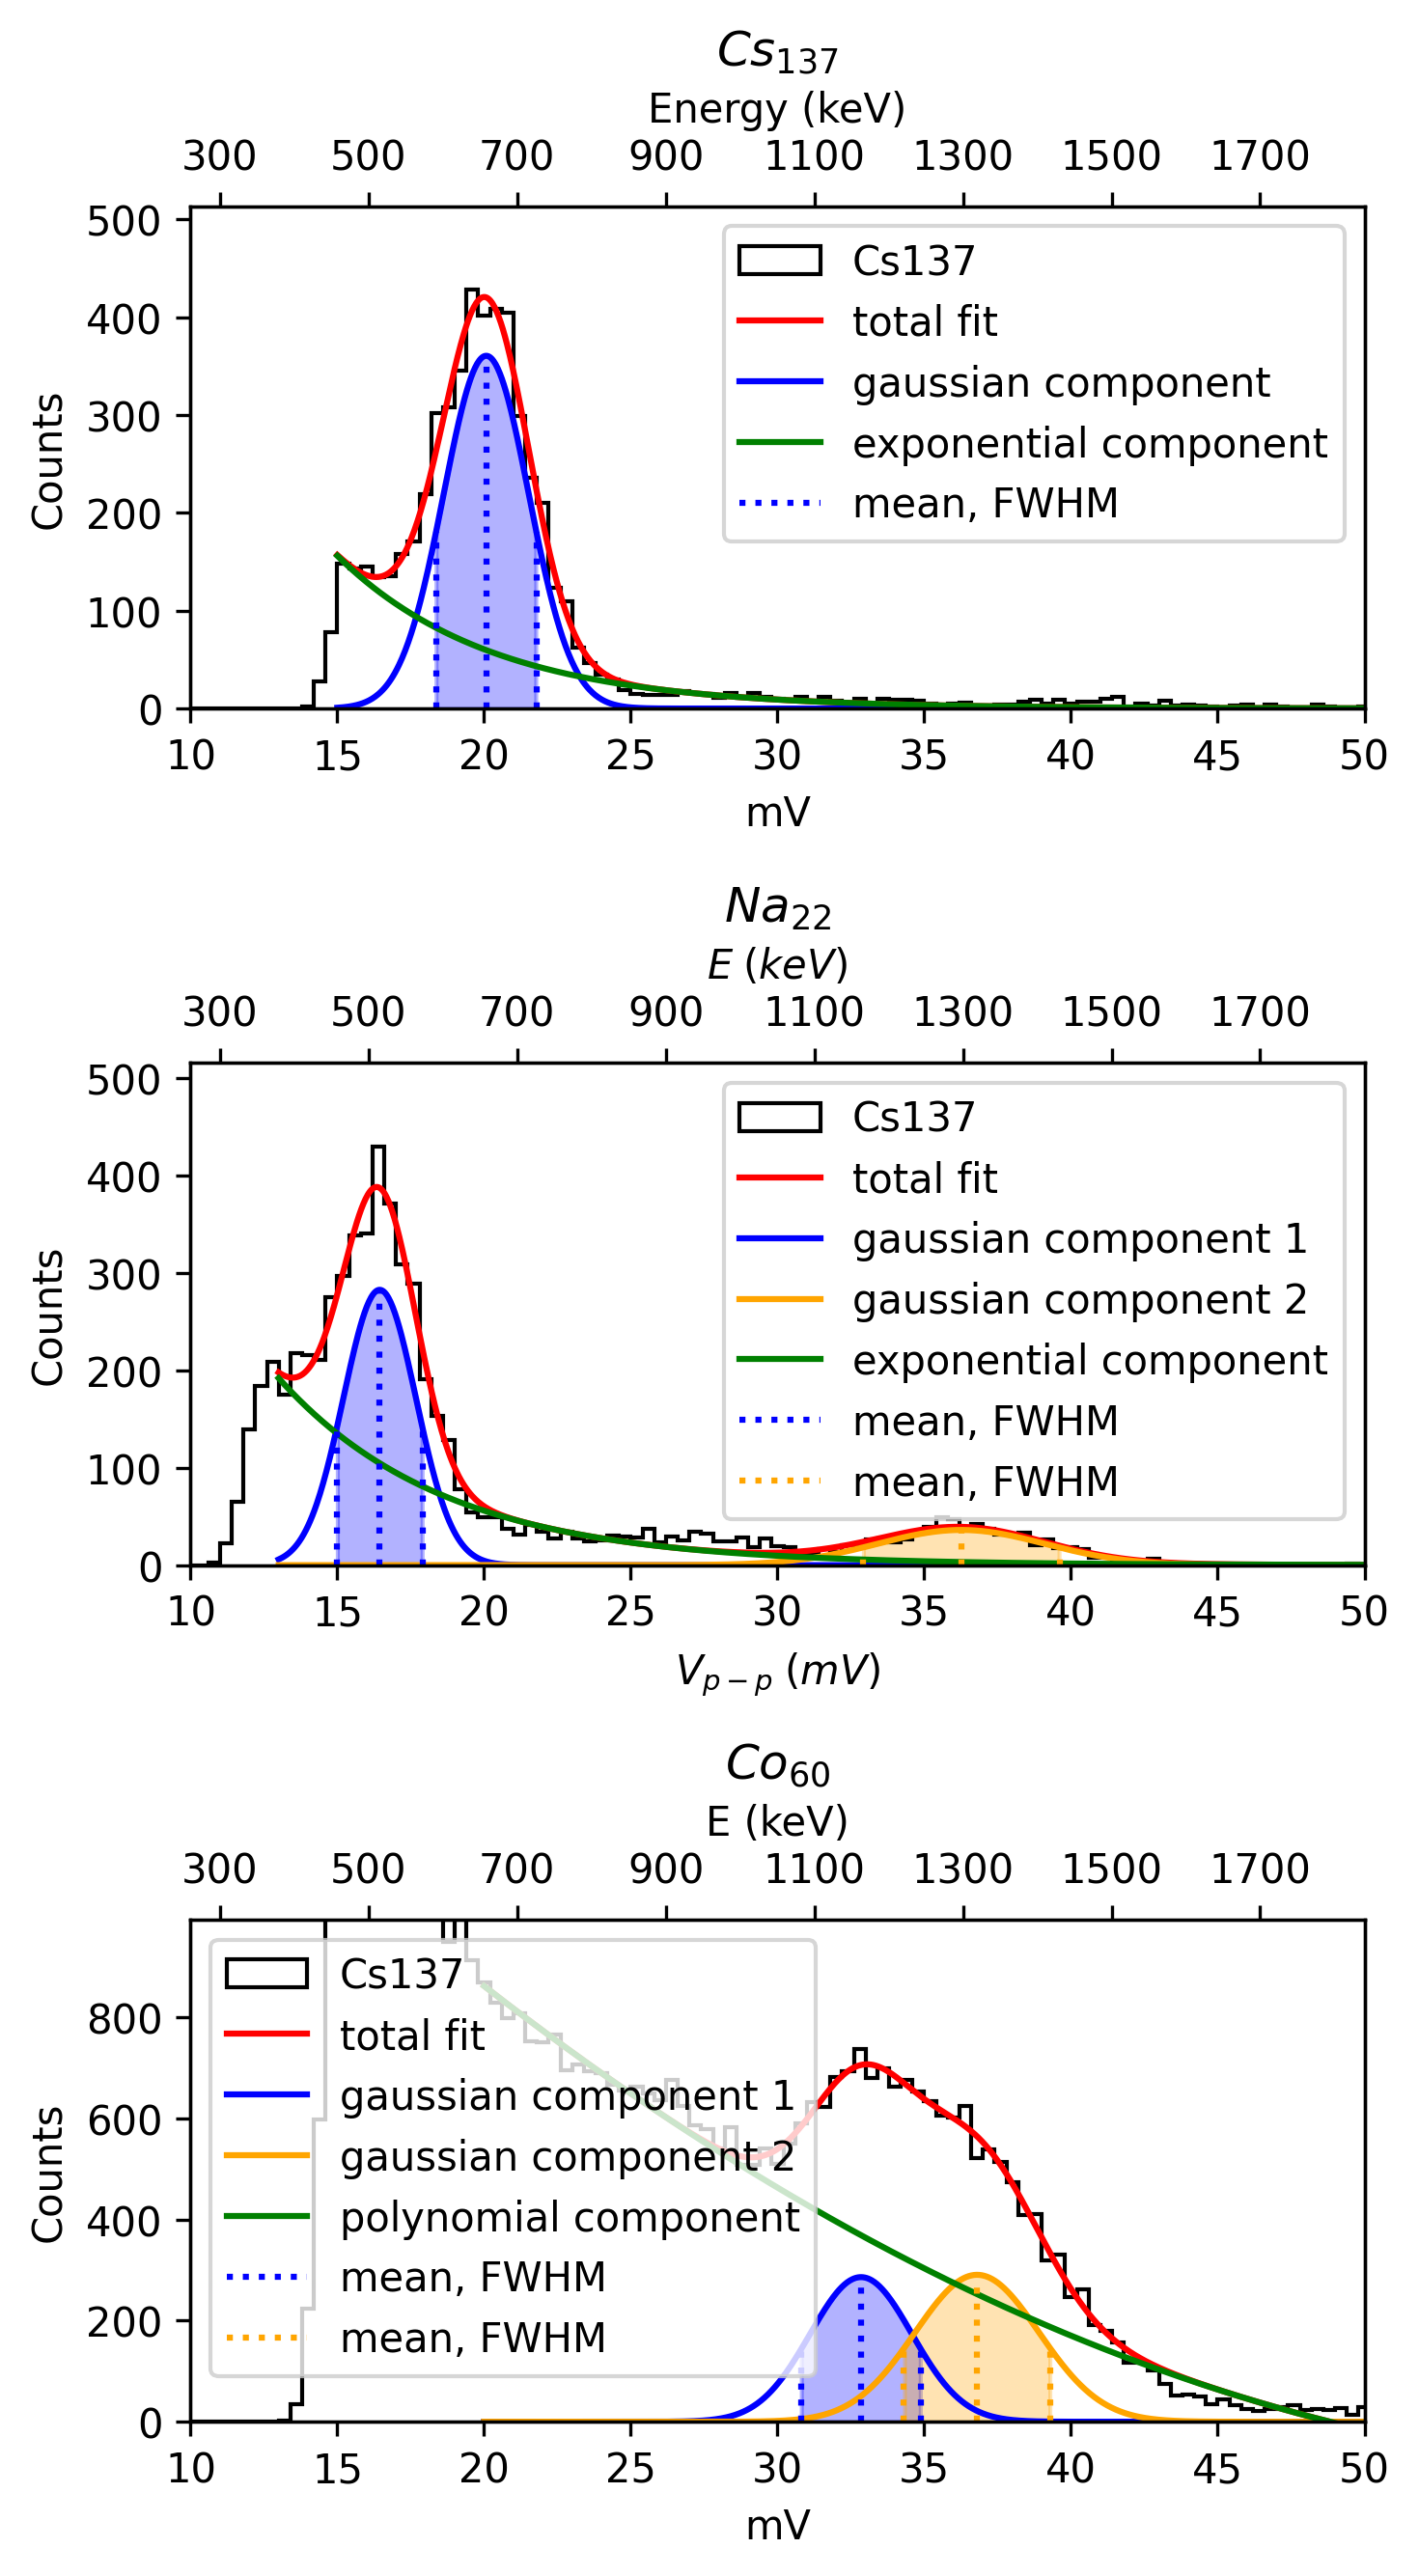

In [253]:
fig, axs = plt.subplots(3,1,figsize=(5,9))
ax=axs[0]
count, bins, _ = ax.hist(Cs137_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])
def fit_func(x, A, mu, sigma, B, tau):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B * np.exp(-x / tau)

fit_range = (15, 50)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
initial_guess = [1e5, 20, 2, 1e4, 10] 

popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0)
y_exponential = fit_func(x_fit, 0, 0, 0, popt[3], popt[4])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian, color='blue', label='gaussian component')
ax.plot(x_fit, y_exponential, color='green', label='exponential component')
fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
peak_middle = popt[1]
ax.vlines(peak_middle, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle - fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle + fwhm/2, 0, popt[0]/2, color='blue', linestyle='dotted')

ax.fill_between(x_fit, y_gaussian, 0, where=(x_fit >= peak_middle - fwhm/2) & (x_fit <= peak_middle + fwhm/2), color='blue', alpha=0.3)
Cs137_peak1_mean=popt[1]
Cs137_peak1_fwhm=fwhm

ax.legend()
ax.set_title(r'$Cs_{137}$')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts') 

#make a second x axis with the energy in keV on top, from 300 to 1200 kev in increments of 100
ax2 = ax.twiny()
ax2.set_xlim(mV_to_keV(min), mV_to_keV(max))
ax2.set_xticks(np.arange(300, 1800, 200))
ax2.set_xticklabels(np.arange(300, 1800, 200))
ax2.set_xlabel('Energy (keV)')




ax=axs[1]
count, bins, _ = ax.hist(Na22_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (13, 50)
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus an exponential curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, tau):
    return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * np.exp(-x / tau)
initial_guess = [1e4, 17, 2, 1e4, 36, 2, 1e4, 10]
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0)
y_exponential = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_exponential, color='green', label='exponential component')
fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
peak_middle1 = popt[1]
peak_middle2 = popt[4]
ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')

ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Na22_peak1_mean=popt[1]
Na22_peak1_fwhm=fwhm1
Na22_peak2_mean=popt[4]
Na22_peak2_fwhm=fwhm2

ax.legend()
ax.set_title(r'$Na_{22}$')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel(r'$V_{p-p} \; (mV)$')
ax.set_ylabel('Counts')
ax2 = ax.twiny()
ax2.set_xlim(mV_to_keV(min), mV_to_keV(max))
ax2.set_xticks(np.arange(300, 1800, 200))
ax2.set_xticklabels(np.arange(300, 1800, 200))
ax2.set_xlabel(r'$E \; (keV)$')

ax = axs[2]
count, bins, _ = ax.hist(Co60_df['mV'], range=(min,max), bins=hist_bins, color='black', label='Cs137', histtype='step')
bin_centers = 0.5*(bins[1:] + bins[:-1])

fit_range = (20, 50)  
counts_fit = count[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
bin_centers_fit = bin_centers[(bins[:-1] >= fit_range[0]) & (bins[:-1] <= fit_range[1])]
# define a fit function - two gauss curves plus a quadratic curve
def fit_func(x, A1, mu1, sigma1, A2, mu2, sigma2, B, C, D):
    return A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2) + B * x**2 + C * x + D
initial_guess = [1e2, 33, 2, 1e2, 36, 2, 1e-1, 1e1,1e3]
popt, pcov = curve_fit(fit_func, bin_centers_fit, counts_fit, p0=initial_guess, maxfev=10000)
x_fit = np.linspace(fit_range[0], fit_range[1], 1000)
y_fit = fit_func(x_fit, *popt)
y_gaussian1 = fit_func(x_fit, popt[0], popt[1], popt[2], 0, 0, 0, 0,0,0)
y_gaussian2 = fit_func(x_fit, 0, 0, 0, popt[3], popt[4], popt[5], 0, 0,0)
y_exponential = fit_func(x_fit, 0, 0, 0, 0, 0, 0, popt[6], popt[7], popt[8])
ax.plot(x_fit, y_fit, color='red', label='total fit')
ax.plot(x_fit, y_gaussian1, color='blue', label='gaussian component 1')
ax.plot(x_fit, y_gaussian2, color='orange', label='gaussian component 2')
ax.plot(x_fit, y_exponential, color='green', label='polynomial component')

fwhm1 = 2 * np.sqrt(2 * np.log(2)) * popt[2]
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * popt[5]
peak_middle1 = popt[1]
peak_middle2 = popt[4]
ax.vlines(peak_middle1, 0, popt[0], color='blue', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle1 - fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle1 + fwhm1/2, 0, popt[0]/2, color='blue', linestyle='dotted')
ax.vlines(peak_middle2, 0, popt[3], color='orange', linestyle='dotted', label='mean, FWHM')
ax.vlines(peak_middle2 - fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.vlines(peak_middle2 + fwhm2/2, 0, popt[3]/2, color='orange', linestyle='dotted')
ax.fill_between(x_fit, y_gaussian1, 0, where=(x_fit >= peak_middle1 - fwhm1/2) & (x_fit <= peak_middle1 + fwhm1/2), color='blue', alpha=0.3)
ax.fill_between(x_fit, y_gaussian2, 0, where=(x_fit >= peak_middle2 - fwhm2/2) & (x_fit <= peak_middle2 + fwhm2/2), color='orange', alpha=0.3)

Co60_peak1_mean=popt[1]
Co60_peak1_fwhm=fwhm1
Co60_peak2_mean=popt[4]
Co60_peak2_fwhm=fwhm2


# present the fit parameters
print('fit parameters:')
for i, param in enumerate(popt):
    print(f'param {i}: {param:.2f}')

ax.legend()
ax.set_title(r'$Co_{60}$')
ax.set_ylim(0, 1.2*np.max(counts_fit))
ax.set_xlim(min, max)
ax.set_xlabel('mV')
ax.set_ylabel('Counts')

ax2 = ax.twiny()
ax2.set_xlim(mV_to_keV(min), mV_to_keV(max))
ax2.set_xticks(np.arange(300, 1800, 200))
ax2.set_xticklabels(np.arange(300, 1800, 200))
ax2.set_xlabel('E (keV)')

plt.show()